## EDA FOR CC CUSTOMERS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.paths import DATA_DIR_RAW, DATA_DIR_PROCESS

In [2]:
data = pd.read_csv(DATA_DIR_RAW / "Churn_Modelling.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [3]:
data=data.drop(["RowNumber","CustomerId","Surname"],axis=1)
data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [4]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Visualise

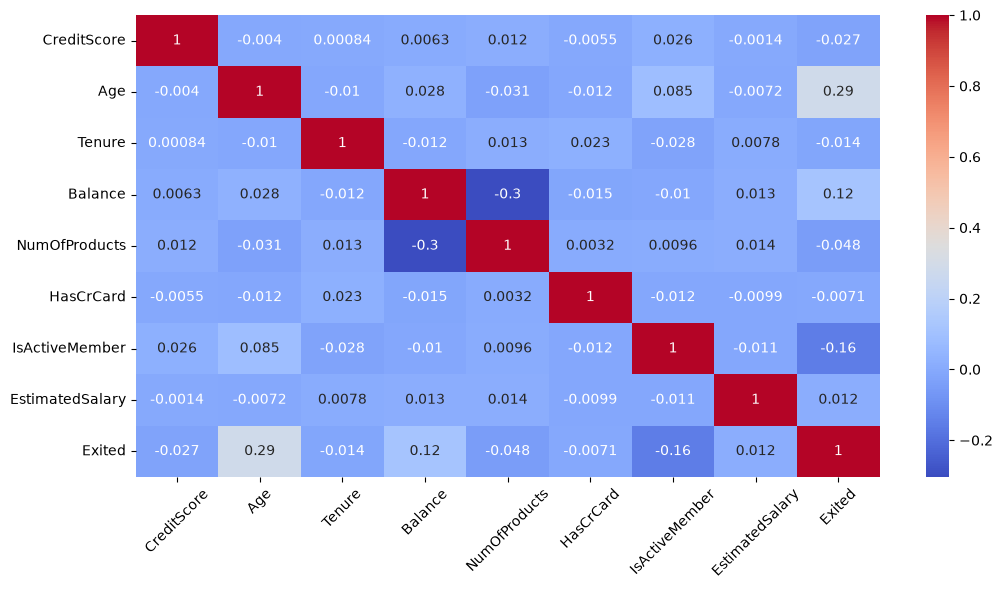

In [5]:
plt.figure(figsize=(12, 6))
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.xticks(rotation=45)
plt.show()


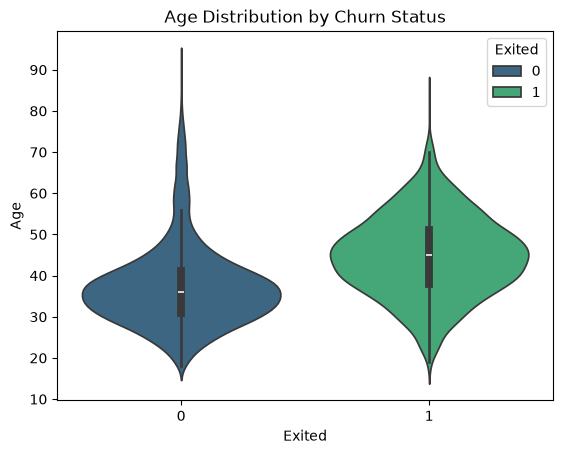

In [6]:

sns.violinplot(data,x='Exited',y="Age",hue='Exited',palette='viridis')
plt.title("Age Distribution by Churn Status")
plt.show()

Text(0.5, 1.0, 'Churn by Geography')

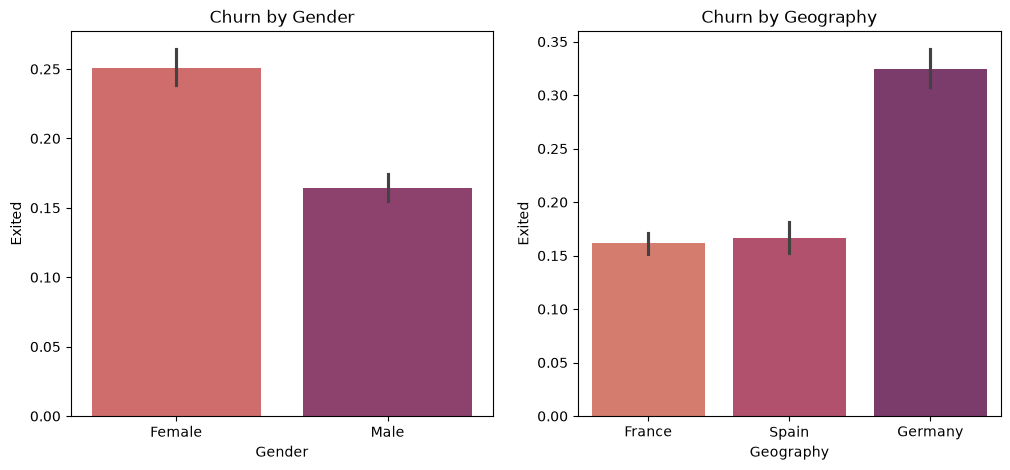

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data,x='Gender',y='Exited',ax=axes[0],palette='flare',hue='Gender')
axes[0].set_title("Churn by Gender")

sns.barplot(data,y='Exited',x='Geography',hue='Geography',palette='flare')
axes[1].set_title("Churn by Geography")

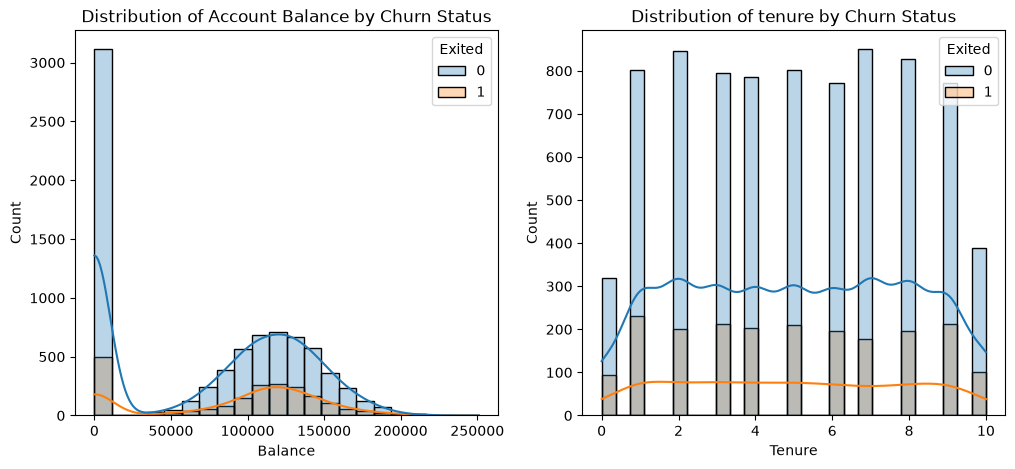

In [8]:
fig , axes =plt.subplots(1,2 , figsize=(12,5))

sns.histplot(data=data, x="Balance", hue="Exited", kde=True, alpha=0.3,ax=axes[0])
axes[0].set_title("Distribution of Account Balance by Churn Status")

sns.histplot(data,x='Tenure',hue='Exited',kde=True ,alpha=0.3)
axes[1].set_title("Distribution of tenure by Churn Status")

plt.show()

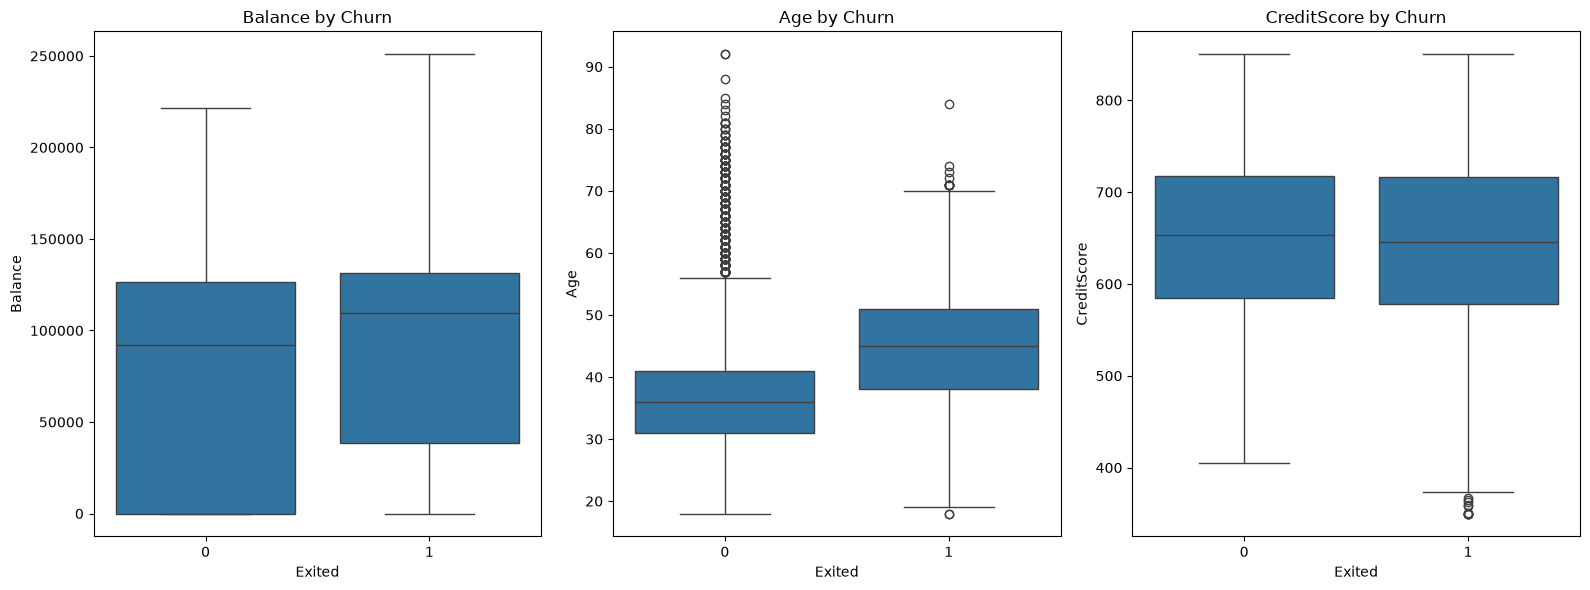

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Compare Balance across Churned vs Retained customers
sns.boxplot(data=data, x="Exited", y="Balance", ax=axes[0])
axes[0].set_title("Balance by Churn")

sns.boxplot(data=data, x="Exited", y="Age", ax=axes[1])
axes[1].set_title("Age by Churn")

sns.boxplot(data=data, x="Exited", y="CreditScore", ax=axes[2])
axes[2].set_title("CreditScore by Churn")

plt.tight_layout()
plt.show()

In [10]:
data.to_csv(DATA_DIR_PROCESS/"cust_churn_cc.csv" , index=False)

## Observations

- Age is the strongest indicator of churn: Customers in their 40s and 50s are churning at a significantly higher rate than younger customers. The median age of a churning customer is roughly 45, whereas the median age of a retained customer is around 36.
- Gender plays a role: Female customers have a noticeably higher churn rate (around 25%) compared to male customers (around 16%).
- Location matters heavily: Customers located in Germany are leaving at twice the rate (over 30%) of customers in France and Spain (both roughly 15-16%).
- The "High Balance" Risk: There is a clear behavioral divide based on account balances. Customers with an empty account ($0 balance) are largely staying with the bank. However, customers with a high balance (in the 75k to 150k range) are churning at a disproportionately higher rate.
- Estimated Salary is largely irrelevant: The heatmap shows almost zero correlation (0.012) between a customer's estimated salary and their likelihood to exit.
- Tenure has no impact: The distribution is completely uniform. Whether a customer has been with the bank for 1 year or 9 years, their likelihood of leaving remains exactly the same.
-Active membership retains customers: As seen in the heatmap's negative correlation (-0.16), customers who are flagged as "Active Members" are noticeably less likely to churn.